<a href="https://colab.research.google.com/github/edent4313-star/climate-challenge-week0/blob/compare-countries/compare_countries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, kruskal

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ethiopia_clean.xlsx to ethiopia_clean.xlsx
Saving sudan_clean.xlsx to sudan_clean.xlsx
Saving Nigeria_clean.xlsx to Nigeria_clean.xlsx
Saving kenya_clean.xlsx to kenya_clean.xlsx
Saving tanzania_clean.xlsx to tanzania_clean.xlsx


In [5]:
# Load data
ethiopia = pd.read_excel("ethiopia_clean.xlsx")
sudan = pd.read_excel("sudan_clean.xlsx")
Nigeria = pd.read_excel("Nigeria_clean.xlsx")
kenya = pd.read_excel("kenya_clean.xlsx")
tanzania = pd.read_excel("tanzania_clean.xlsx")

In [6]:
ethiopia['Country'] = 'Ethiopia'
sudan['Country'] = 'sudan'
Nigeria['Country'] = 'Nigeria'
kenya['Country'] = 'kenya'
tanzania['Country'] = 'tanzania'

In [9]:
df = pd.concat([
    ethiopia,
    sudan,
    Nigeria,
    kenya,
    tanzania
], ignore_index=True)



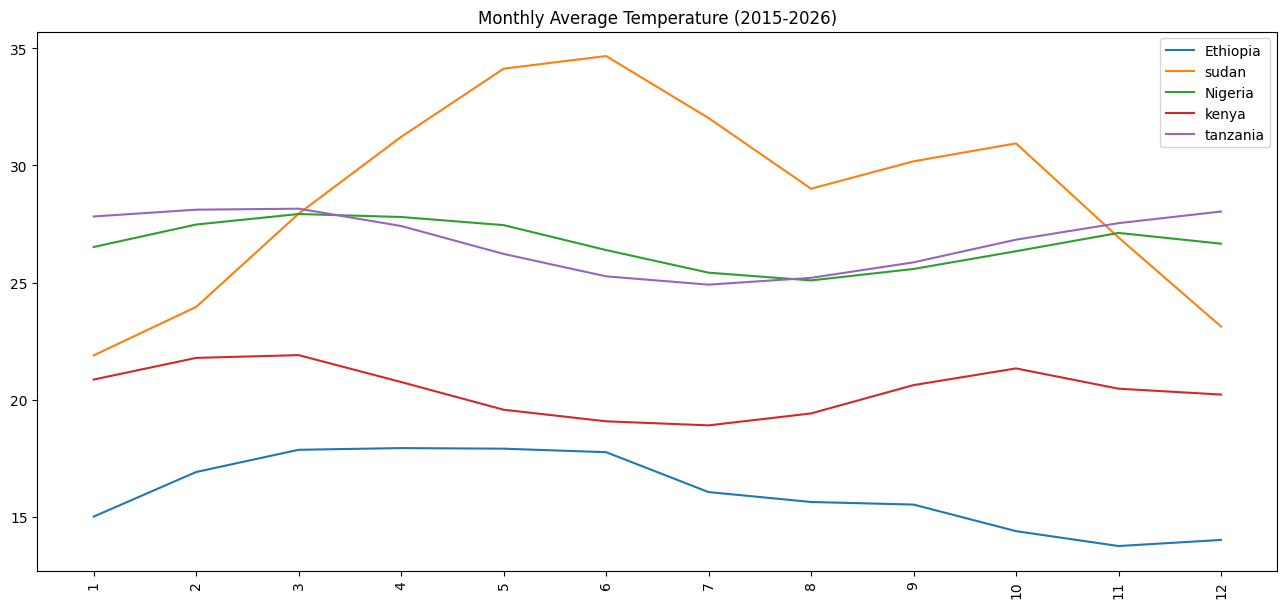

In [10]:
monthly_temp = df.groupby(['Month','Country'])['T2M'].mean().reset_index()
monthly_temp['Month'] = monthly_temp['Month'].astype(str)

plt.figure(figsize=(16,7))

for country in df['Country'].unique():
    temp = monthly_temp[monthly_temp['Country']==country]
    plt.plot(temp['Month'], temp['T2M'], label=country)

plt.xticks(rotation=90)
plt.title("Monthly Average Temperature (2015-2026)")
plt.legend()
plt.show()

In [11]:
temp_summary = df.groupby('Country')['T2M'].agg(['mean','median','std']).round(2)
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.07,16.04,1.90
Nigeria,26.66,26.82,1.12
kenya,20.43,20.36,1.44
sudan,28.76,29.16,4.68
tanzania,26.80,26.99,1.33


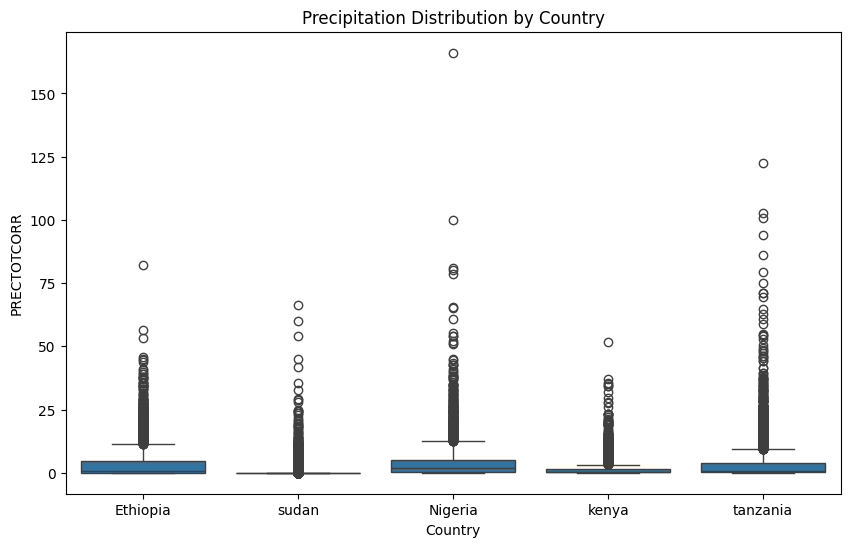

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Country', y='PRECTOTCORR')
plt.title("Precipitation Distribution by Country")
plt.show()

In [13]:
rain_summary = df.groupby('Country')['PRECTOTCORR'].agg(['mean','median','std']).round(2)
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.63,0.82,6.29
Nigeria,4.21,1.84,7.27
kenya,1.47,0.38,3.18
sudan,0.64,0.00,3.06
tanzania,3.74,0.64,8.00


In [15]:
groups = [group['T2M'].dropna() for name, group in df.groupby('Country')]

anova = f_oneway(*groups)
print("ANOVA p-value:", anova.pvalue)

ANOVA p-value: 0.0


In [17]:
rank = df.groupby('Country').agg({
    'T2M':'mean',
    'PRECTOTCORR':'std',
    'T2M_MAX':'max'
}).round(2)

rank.columns = ['Avg Temp','Rain Variability','Max Temp']

rank['Score'] = rank['Avg Temp'] + rank['Rain Variability'] + rank['Max Temp']
rank = rank.sort_values('Score', ascending=False)

rank

,Avg Temp,Rain Variability,Max Temp,Score
Country,,,,
sudan,28.76,3.06,45.96,77.78
tanzania,26.80,8.00,33.93,68.73
Nigeria,26.66,7.27,32.88,66.81
kenya,20.43,3.18,34.27,57.88
Ethiopia,16.07,6.29,30.93,53.29
